In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model


In [5]:
df_lin = pd.read_csv('voltage_soc_linear.csv')
df_exp = pd.read_csv('voltage_soc_exponential.csv')
df_log = pd.read_csv('voltage_soc_logarithmic.csv')

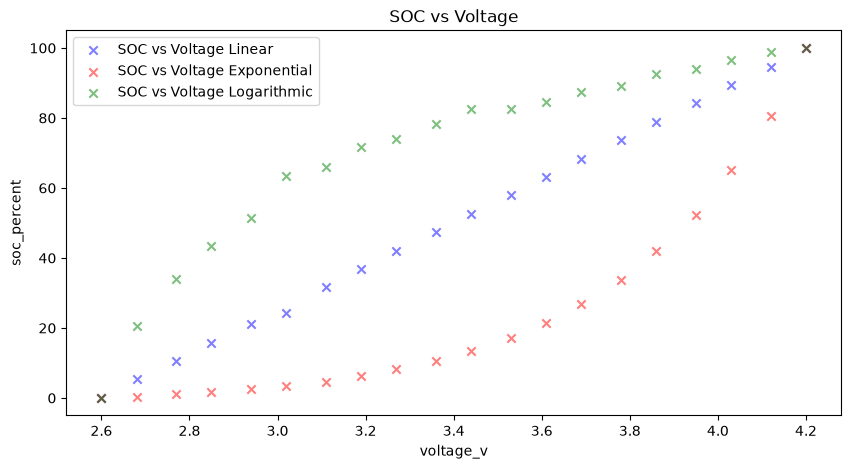

In [6]:
plt.figure(figsize=(10, 5))
plt.title('SOC vs Voltage') 
plt.xlabel('voltage_v')
plt.ylabel('soc_percent')
plt.scatter(df_lin['voltage_v'], df_lin['soc_percent'], label='SOC vs Voltage Linear', color='blue', alpha=0.5,marker='x')
plt.scatter(df_exp['voltage_v'], df_exp['soc_percent'], label='SOC vs Voltage Exponential', color='red' , alpha=0.5,marker='x')
plt.scatter(df_log['voltage_v'], df_log['soc_percent'], label='SOC vs Voltage Logarithmic', color='green',alpha=0.5,marker='x')
plt.legend()
plt.show()

In [7]:
#test data to plot
vtg_s = [2.4, 2.8, 3.0, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.1]
vtg_s = pd.DataFrame(vtg_s, columns=['voltage_v'])

#linear 
reg_lin = linear_model.LinearRegression()
reg_lin.fit(df_lin[['voltage_v']], df_lin['soc_percent'])
df_predict = pd.DataFrame(vtg_s, columns=['voltage_v'])
soc_s_lin = reg_lin.predict(df_predict)

#exponential
reg_exp = linear_model.LinearRegression()
exp = np.exp(df_exp[['voltage_v']])
reg_exp.fit(exp, df_exp['soc_percent'])
df_predict = pd.DataFrame(vtg_s, columns=['voltage_v'])
soc_s_exp = reg_exp.predict(np.exp(df_predict))

#logarithmic
reg_log = linear_model.LinearRegression()
log = np.log(df_log[['voltage_v']])
reg_log.fit(log, df_log['soc_percent'])
df_predict = pd.DataFrame(vtg_s, columns=['voltage_v'])
soc_s_log = reg_log.predict(np.log(df_predict))


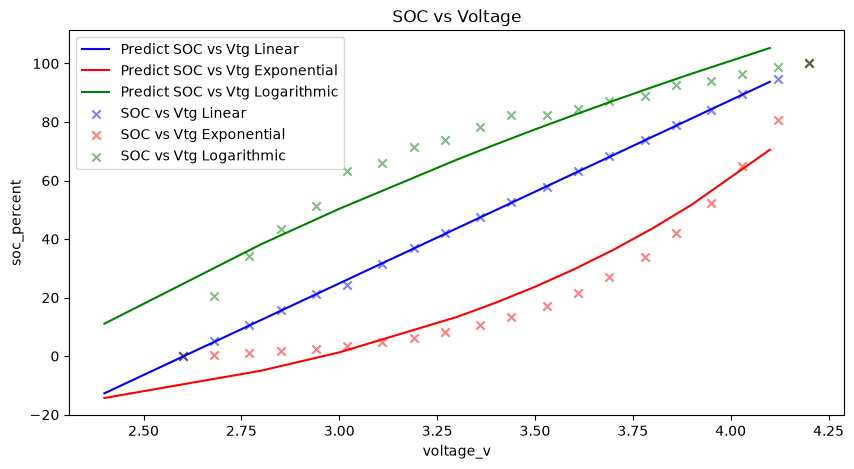

In [8]:
plt.figure(figsize=(10, 5))
plt.title('SOC vs Voltage') 
plt.xlabel('voltage_v')
plt.ylabel('soc_percent')

plt.plot(vtg_s, soc_s_lin,color='blue',  label='Predict SOC vs Vtg Linear')
plt.plot(vtg_s, soc_s_exp,color='red',   label='Predict SOC vs Vtg Exponential')
plt.plot(vtg_s, soc_s_log,color='green', label='Predict SOC vs Vtg Logarithmic')

plt.scatter(df_lin['voltage_v'], df_lin['soc_percent'], label='SOC vs Vtg Linear', color='blue', alpha=0.5,marker='x')
plt.scatter(df_exp['voltage_v'], df_exp['soc_percent'], label='SOC vs Vtg Exponential', color='red' , alpha=0.5,marker='x')
plt.scatter(df_log['voltage_v'], df_log['soc_percent'], label='SOC vs Vtg Logarithmic', color='green',alpha=0.5,marker='x')

plt.legend()
plt.show()

In [9]:
# ==============================================================================
#             EXTRACTING COEFFICIENTS, INTERCEPTS & R² SCORES
# ==============================================================================

# 1. LINEAR MODEL
coef_lin = reg_lin.coef_[0]
intercept_lin = reg_lin.intercept_
r2_lin = reg_lin.score(df_lin[['voltage_v']], df_lin['soc_percent'])

print("【 1. LINEAR MODEL 】")
print(f"  • Coefficient (Slope)   : {coef_lin:.4f}")
print(f"  • Intercept (Bias)       : {intercept_lin:.4f}")
print(f"  • R-squared Score        : {r2_lin:.4f} ({r2_lin * 100:.1f}%)")
print(f"  • C++ Deployment Formula : SoC = ({coef_lin:.4f} * voltage) + ({intercept_lin:.4f});")
print("-" * 70)


# 2. EXPONENTIAL MODEL
coef_exp = reg_exp.coef_[0]
intercept_exp = reg_exp.intercept_
# Must pass the exact transformed feature (np.exp) used during training to evaluate the score
r2_exp = reg_exp.score(np.exp(df_exp[['voltage_v']]), df_exp['soc_percent'])

print("【 2. EXPONENTIAL MODEL 】")
print(f"  • Coefficient (Slope)   : {coef_exp:.4f}")
print(f"  • Intercept (Bias)       : {intercept_exp:.4f}")
print(f"  • R-squared Score        : {r2_exp:.4f} ({r2_exp * 100:.1f}%)")
print(f"  • C++ Deployment Formula : SoC = ({coef_exp:.4f} * exp(voltage)) + ({intercept_exp:.4f});")
print("-" * 70)


# 3. LOGARITHMIC MODEL
coef_log = reg_log.coef_[0]
intercept_log = reg_log.intercept_
# Must pass the exact transformed feature (np.log) used during training to evaluate the score
r2_log = reg_log.score(np.log(df_log[['voltage_v']]), df_log['soc_percent'])

print("【 3. LOGARITHMIC MODEL 】")
print(f"  • Coefficient (Slope)   : {coef_log:.4f}")
print(f"  • Intercept (Bias)       : {intercept_log:.4f}")
print(f"  • R-squared Score        : {r2_log:.4f} ({r2_log * 100:.1f}%)")
print(f"  • C++ Deployment Formula : SoC = ({coef_log:.4f} * log(voltage)) + ({intercept_log:.4f});")
print("=" * 70)


【 1. LINEAR MODEL 】
  • Coefficient (Slope)   : 62.6211
  • Intercept (Bias)       : -163.0166
  • R-squared Score        : 0.9998 (100.0%)
  • C++ Deployment Formula : SoC = (62.6211 * voltage) + (-163.0166);
----------------------------------------------------------------------
【 2. EXPONENTIAL MODEL 】
  • Coefficient (Slope)   : 1.7204
  • Intercept (Bias)       : -33.2878
  • R-squared Score        : 0.9307 (93.1%)
  • C++ Deployment Formula : SoC = (1.7204 * exp(voltage)) + (-33.2878);
----------------------------------------------------------------------
【 3. LOGARITHMIC MODEL 】
  • Coefficient (Slope)   : 175.9327
  • Intercept (Bias)       : -142.9518
  • R-squared Score        : 0.8953 (89.5%)
  • C++ Deployment Formula : SoC = (175.9327 * log(voltage)) + (-142.9518);
